https://gemini.google.com/share/5534eda61953

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Modules
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
# from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

# --- ALGORITHM IMPORTS (Keep these handy to swap out) ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsRegressor

# from sklearn.compose import TransformedTargetRegressor
import numpy as np
from sklearn.linear_model import LinearRegression

from sklearn.linear_model import ElasticNet
# ==========================================
# 1. SETUP & DATA SPLITTING
# ==========================================
# (Generating a dummy dataset with mixed types for demonstration)
# X_num, y = make_classification(n_samples=500, n_features=10, n_informative=5, random_state=42)
# df = pd.DataFrame(X_num, columns=[f'num_feature_{i}' for i in range(10)])
# df['cat_feature_1'] = np.random.choice(['A', 'B', 'C'], 500) # Add a categorical column
# X = df

df = pd.read_csv("./as3/train.csv")



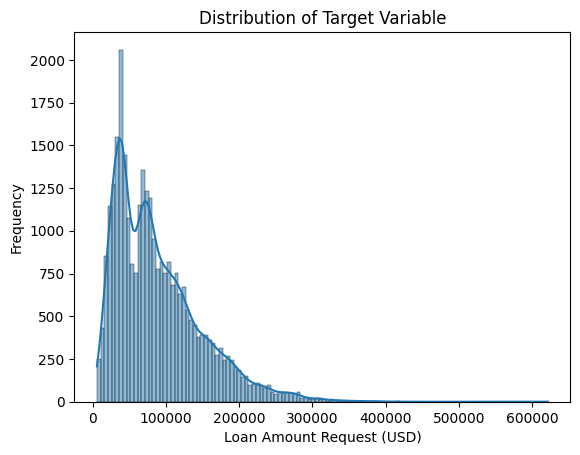

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns


# ==========================================
#EDA

#distribution of target variable
sns.histplot(df['Loan Amount Request (USD)'], kde=True)
plt.title("Distribution of Target Variable")
plt.xlabel("Loan Amount Request (USD)")
plt.ylabel("Frequency")
plt.show()

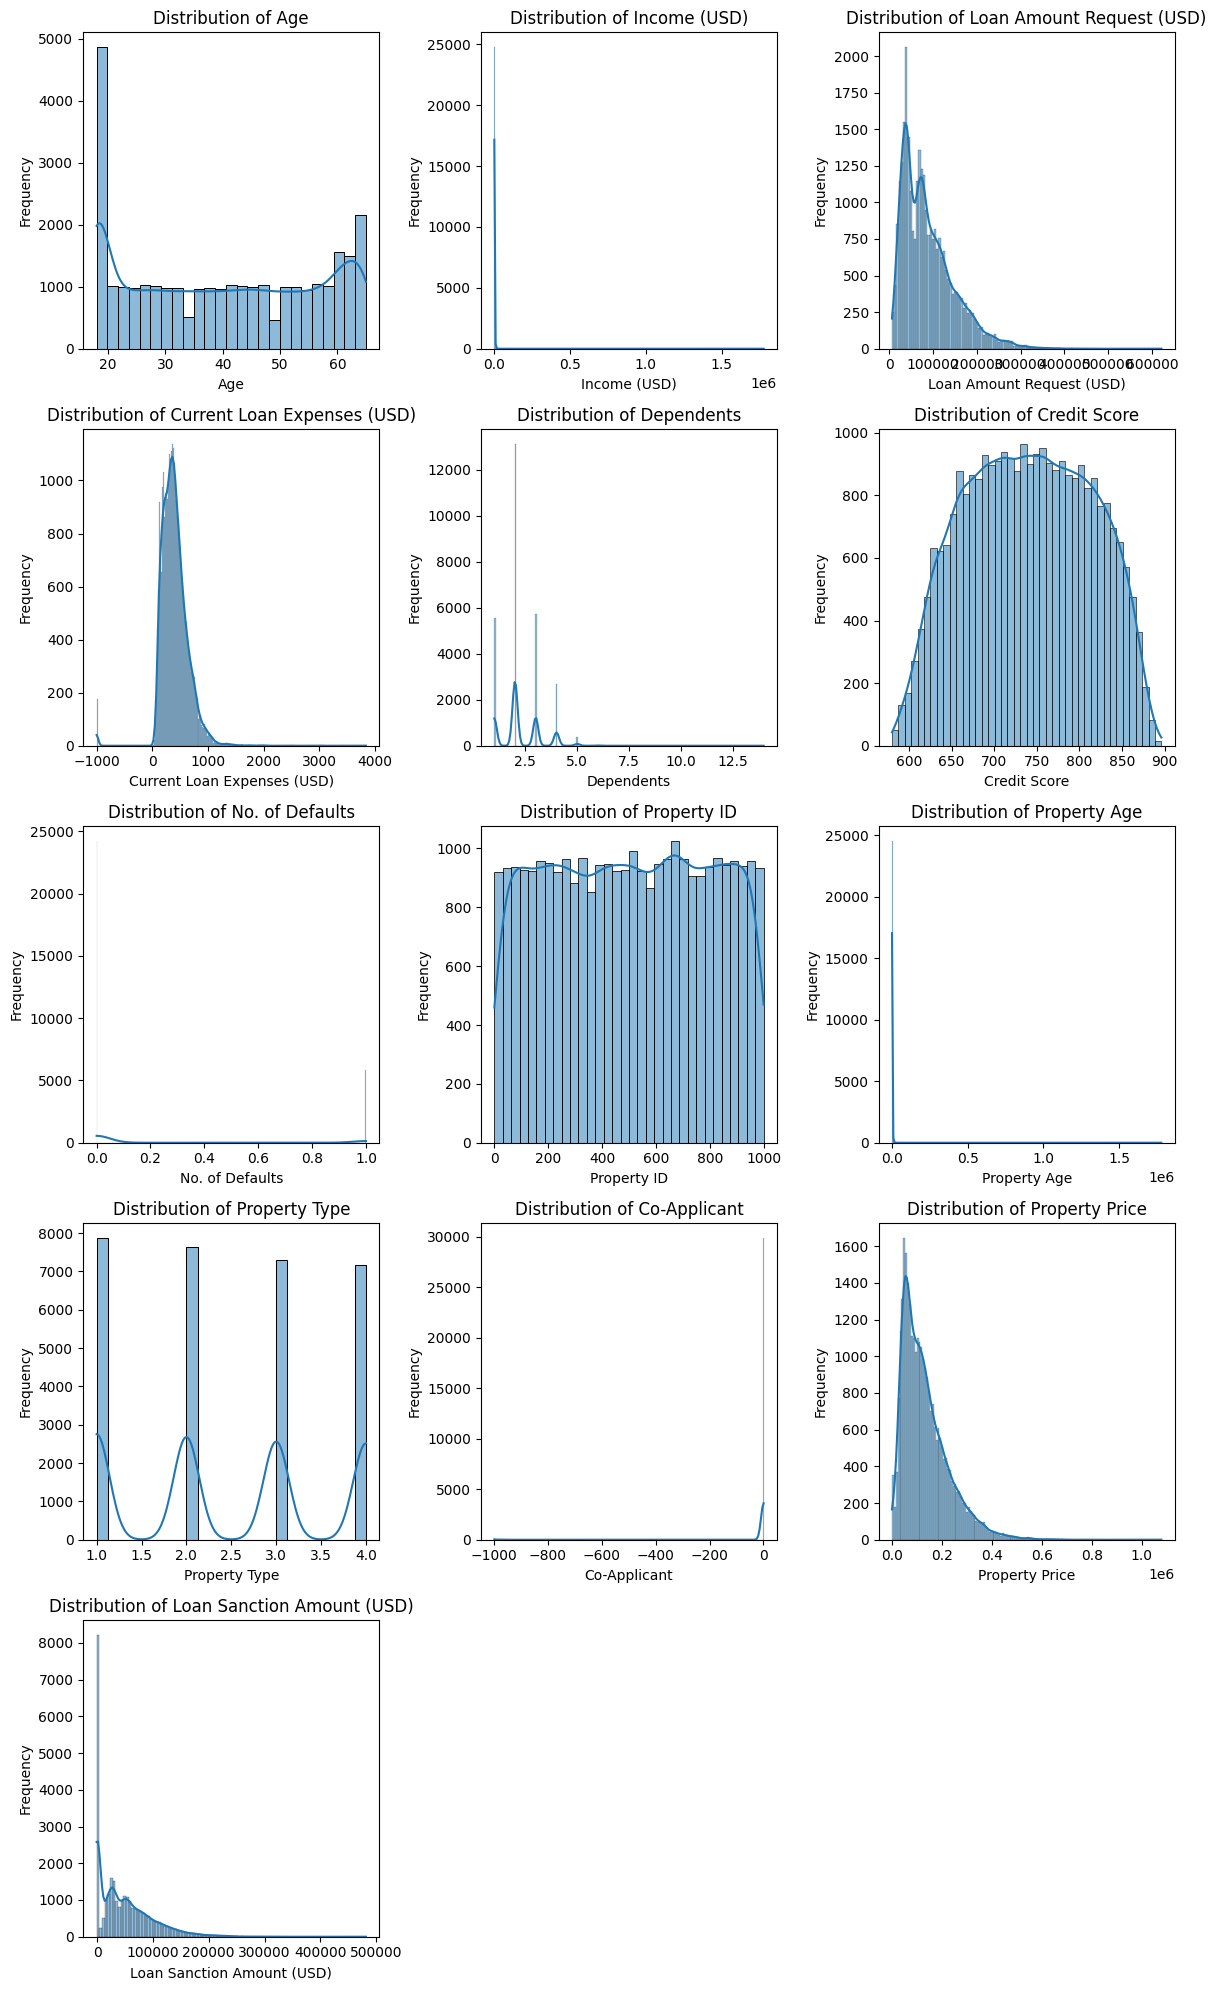

In [126]:
import math
# Get the numerical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
n_features = len(num_cols)

# Set up the subplot grid (e.g., 2 columns wide)
grid_cols = 3
grid_rows = math.ceil(n_features / grid_cols)

# Create the figure and axes
fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(12, 4 * grid_rows))

# Flatten the axes array so we can easily iterate over it in a 1D loop
if n_features > 1:
    axes = axes.flatten()
else:
    axes = [axes]

# Loop through columns and plot on the grid
for i, col in enumerate(num_cols):
    ax = axes[i] # Select the current axis
    
    # Plot directly onto the specific axis using ax=ax
    sns.histplot(df[col], kde=True, ax=ax)
    
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency") 

# Clean up any empty subplots if the number of features is odd
for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

# Adjust spacing and display
plt.tight_layout()
plt.show()

1. # **~~_~~`AFTER EDA`~~_~~**

In [127]:
df = df.dropna(subset=['Loan Sanction Amount (USD)'])

In [128]:
X = df.drop(['Loan Sanction Amount (USD)', 'Customer ID',"Name"], axis=1)  # Assuming 'Loan Amount Request (USD)' is the label column
y = df['Loan Sanction Amount (USD)']

In [129]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# ==========================================
# 2. THE COLUMN TRANSFORMER (Traffic Router)
# ==========================================
# Identify which columns are numbers and which are categories
numeric_features = [col for col in X.columns if X[col].dtype != 'object']
categorical_features = [col for col in X.columns if X[col].dtype == 'object']


In [ ]:

# Lane 1: Numerical Data Pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Fill missing numbers with median
    ('scaler', StandardScaler())                   # Standardize the numbers
])
# Lane 2: Categorical Data Pipeline
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), # Fill missing text with mode
    ('ohe', OneHotEncoder(handle_unknown='ignore'))       # Convert text to binary columns
])

# Merge the lanes
#List of (name, transformer, columns) tuples specifying the transformer objects to be applied to subsets of the data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


# ==========================================
# 3. THE MASTER PIPELINE
# ==========================================
pipe = Pipeline([
    ('preprocessor', preprocessor), # 1. Clean and scale everything
   # ('pca', PCA()),                 # 2. Compress the features, not there for portions
    # ('classifier', LogisticRegression()) # 3. Train the model




    # --- SWAPPING MODELS FOR EXAMS ---
    # To change models, just change the line above. Examples:
    # ('classifier', SVC(kernel='rbf'))
    # ('classifier', RandomForestClassifier())
    # ('classifier', KNeighborsClassifier())

    #for linear regression, we would import and use LinearRegression instead of LogisticRegression, and adjust the target variable accordingly (e.g., for regression tasks instead of classification).
    # ('regression', LinearRegression())
    # ('regression',ElasticNet())
    ('regression',KNeighborsRegressor())
    #  ('regression', SVR())
])

# ==========================================
# 4. GRID SEARCH (Hyperparameter Tuning)
# ==========================================
# Note: You can even tune PCA's parameters here!
param_grid = {
    # 'pca__n_components': [2, 3, 5], # Test keeping 2, 3, or 5 principal components
    # 'classifier__C': [0.1, 1.0, 10.0] # Logistic Regression tuning

    # --- SWAPPING PARAMETERS ---
    # If using RandomForest:
    # 'classifier__n_estimators': [50, 100],
    # 'classifier__max_depth': [None, 5, 10]

    # If using KNN:
    # 'classifier__n_neighbors': [3, 5, 7]


    # 'regression__C': [0.1, 1.0],
    # 'regression__epsilon': [0.1, 0.2],
    # 'regression__kernel': ['rbf', 'linear'],

        # 'regression__alpha': [0.1, 1.0, 10.0],
        # 'regression__l1_ratio': [0.1, 0.5, 0.9]


}

print("Running Grid Search...")
grid = GridSearchCV(pipe, param_grid, cv=5, scoring=['r2'], n_jobs=-1,return_train_score=True)
grid.fit(X_train, y_train)

print(f"Best Parameters Found: {grid.best_params_}")
print(f"Test Set Accuracy: {grid.score(X_test, y_test):.4f}")

# ==========================================
# 5. POST-EDA VISUALIZATIONS
# ==========================================

# --- A. PCA PLOT (PC1 vs PC2) ---
# Pro-Tip: To plot PCA correctly, we must pass the test data through the pipeline
# *up to the PCA step*, stopping before the classifier.
# grid.best_estimator_[:-1] slices the pipeline to exclude the final classifier step!
# pca_pipeline = grid.best_estimator_[:-1]
# X_test_pca = pca_pipeline.transform(X_test)
#
# plt.figure(figsize=(8, 6))
# # Plot PC1 (column 0) vs PC2 (column 1), colored by the actual target labels
# scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='viridis', alpha=0.7)
# plt.title("PCA: PC1 vs PC2")
# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.legend(*scatter.legend_elements(), title="Classes")
# plt.grid(True)
# plt.show()

# # --- B. CONFUSION MATRIX ---
# ConfusionMatrixDisplay.from_estimator(grid, X_test, y_test, cmap='Blues')
# plt.title("Confusion Matrix (with PCA)")
# plt.show()

# --- C. ROC CURVE ---
# RocCurveDisplay.from_estimator(grid, X_test, y_test)
# plt.title("ROC Curve (with PCA)")
# plt.plot([0, 1], [0, 1], 'r--') # Add diagonal chance line
# plt.show()

Running Grid Search...


InvalidParameterError: The 'scoring' parameter of check_scoring must be a str among {'balanced_accuracy', 'jaccard', 'explained_variance', 'recall_macro', 'neg_log_loss', 'r2', 'jaccard_macro', 'precision_micro', 'precision', 'f1_samples', 'f1_macro', 'recall_micro', 'd2_absolute_error_score', 'neg_negative_likelihood_ratio', 'f1_weighted', 'd2_log_loss_score', 'rand_score', 'v_measure_score', 'matthews_corrcoef', 'normalized_mutual_info_score', 'roc_auc_ovr_weighted', 'jaccard_samples', 'homogeneity_score', 'neg_max_error', 'top_k_accuracy', 'roc_auc_ovo_weighted', 'jaccard_weighted', 'completeness_score', 'fowlkes_mallows_score', 'roc_auc_ovr', 'neg_mean_gamma_deviance', 'mutual_info_score', 'precision_samples', 'roc_auc', 'adjusted_rand_score', 'average_precision', 'neg_root_mean_squared_log_error', 'precision_weighted', 'recall_weighted', 'neg_mean_poisson_deviance', 'accuracy', 'neg_mean_squared_log_error', 'neg_mean_absolute_percentage_error', 'neg_root_mean_squared_error', 'jacc

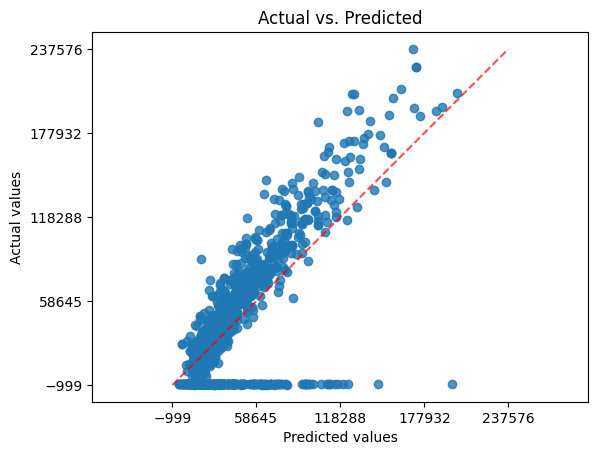

In [131]:
from sklearn.metrics import PredictionErrorDisplay

# 1. Generate the display object
display = PredictionErrorDisplay.from_estimator(
    grid,
    X_test,
    y_test,
    kind="actual_vs_predicted"
)

# 2. Access the 'scatter' object directly to change alpha or color
# This is a safe 'hack' for any scikit-learn display object
plt.setp(display.line_, color='red', linestyle='--') # Format the reference line
plt.title("Actual vs. Predicted")
plt.show()

In [141]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, grid.predict(X_test))
mse = mean_squared_error(y_test, grid.predict(X_test)       )
rmse = np.sqrt(mse)
r2 = r2_score(y_test, grid.predict(X_test))

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 23020.597204387825
MSE: 1071008846.775967
RMSE: 32726.271507398564
R2 Score: 0.5281430729521998


In [132]:
def report_all_performance(model_grid, X_test, y_test, is_regression=False):
    """
    Pass the grid and data, get all mandatory lab plots instantly.
    """
    import matplotlib.pyplot as plt

    if is_regression:
        from sklearn.metrics import PredictionErrorDisplay
        fig, ax = plt.subplots(1, 2, figsize=(12, 5))

        # Plot 1: Actual vs Predicted
        PredictionErrorDisplay.from_estimator(model_grid, X_test, y_test, kind="actual_vs_predicted", ax=ax[0])
        ax[0].set_title("Actual vs. Predicted")

        # Plot 2: Residuals
        PredictionErrorDisplay.from_estimator(model_grid, X_test, y_test, kind="residual_vs_predicted", ax=ax[1])
        ax[1].set_title("Residuals Plot")

    else:
        from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
        fig, ax = plt.subplots(1, 2, figsize=(12, 5))

        # Plot 1: Confusion Matrix
        ConfusionMatrixDisplay.from_estimator(model_grid, X_test, y_test, cmap='Blues', ax=ax[0])
        ax[0].set_title("Confusion Matrix")

        # Plot 2: ROC Curve
        RocCurveDisplay.from_estimator(model_grid, X_test, y_test, ax=ax[1])
        ax[1].plot([0, 1], [0, 1], 'r--')
        ax[1].set_title("ROC Curve")

    plt.tight_layout()
    plt.show()

# USAGE IN EXAM:
# For Exp 2 & 4: report_all_performance(grid, X_test, y_test, is_regression=False)
# For Exp 3: report_all_performance(grid, X_test, y_test, is_regression=True)

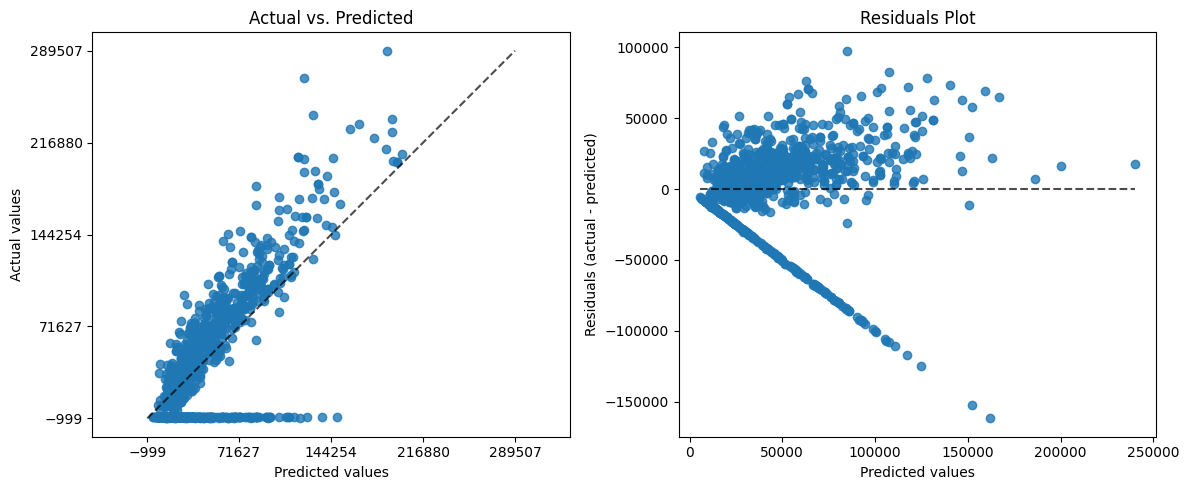

In [133]:
report_all_performance(grid, X_test, y_test, is_regression=True)

In [ ]:
results = pd.DataFrame(grid.cv_results_)
results[results['rank_test_score']==1]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_regression__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
11,0.180795,0.014148,1.118708,0.027013,14,{'regression__n_neighbors': 14},0.533134,0.53686,0.580112,0.568595,...,0.549621,0.020655,1,0.614128,0.61525,0.597197,0.604086,0.616421,0.609416,0.007524


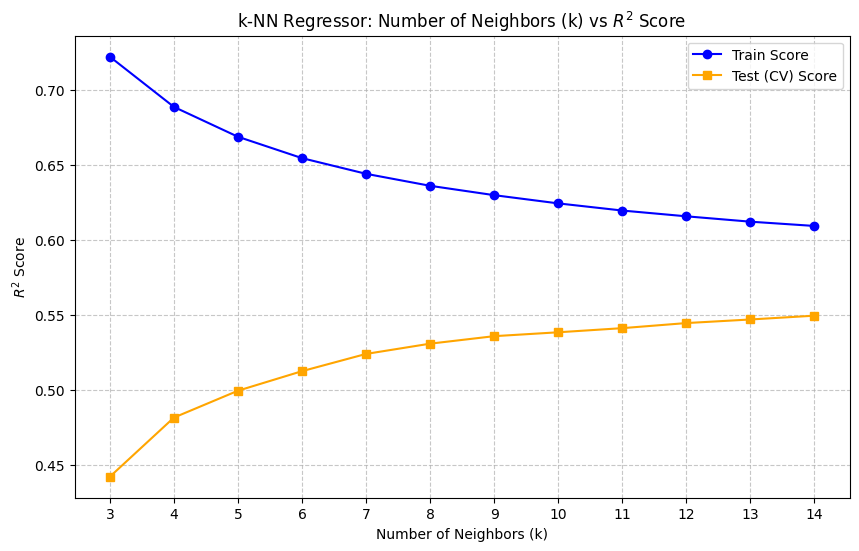

In [135]:
import matplotlib.pyplot as plt

# Extracting the values from the results DataFrame
k_values = results['param_regression__n_neighbors']
mean_train_scores = results['mean_train_score']
mean_test_scores = results['mean_test_score']

# Create the plot
plt.figure(figsize=(10, 6))

# Plot training and testing scores
plt.plot(k_values, mean_train_scores, marker='o', linestyle='-', color='blue', label='Train Score')
plt.plot(k_values, mean_test_scores, marker='s', linestyle='-', color='orange', label='Test (CV) Score')

# Add labels, title, and legend
plt.title('k-NN Regressor: Number of Neighbors (k) vs $R^2$ Score')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('$R^2$ Score')
plt.xticks(k_values) # Ensure all k-values show up on the x-axis
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.show()

In [136]:
# Extract the mean scores
mean_train_score = results['mean_train_score'].iloc[0]
mean_test_score = results['mean_test_score'].iloc[0]

print(f"Mean Training R2 Score: {mean_train_score:.4f}")
print(f"Mean Test (CV) R2 Score: {mean_test_score:.4f}")

# Interpretation:
# - High Train, Low Test = Overfitting
# - Low Train, Low Test = Underfitting
# - High Train, High Test (and close) = Good Fit

Mean Training R2 Score: 0.7222
Mean Test (CV) R2 Score: 0.4423


In [137]:
help(SVR)

Help on class SVR in module sklearn.svm._classes:

class SVR(sklearn.base.RegressorMixin, sklearn.svm._base.BaseLibSVM)
 |  SVR(*, kernel='rbf', degree=3, gamma='scale', coef0=0.0, tol=0.001, C=1.0, epsilon=0.1, shrinking=True, cache_size=200, verbose=False, max_iter=-1)
 |  
 |  Epsilon-Support Vector Regression.
 |  
 |  The free parameters in the model are C and epsilon.
 |  
 |  The implementation is based on libsvm. The fit time complexity
 |  is more than quadratic with the number of samples which makes it hard
 |  to scale to datasets with more than a couple of 10000 samples. For large
 |  datasets consider using :class:`~sklearn.svm.LinearSVR` or
 |  :class:`~sklearn.linear_model.SGDRegressor` instead, possibly after a
 |  :class:`~sklearn.kernel_approximation.Nystroem` transformer or
 |  other :ref:`kernel_approximation`.
 |  
 |  Read more in the :ref:`User Guide <svm_regression>`.
 |  
 |  Parameters
 |  ----------
 |  kernel : {'linear', 'poly', 'rbf', 'sigmoid', 'precomput

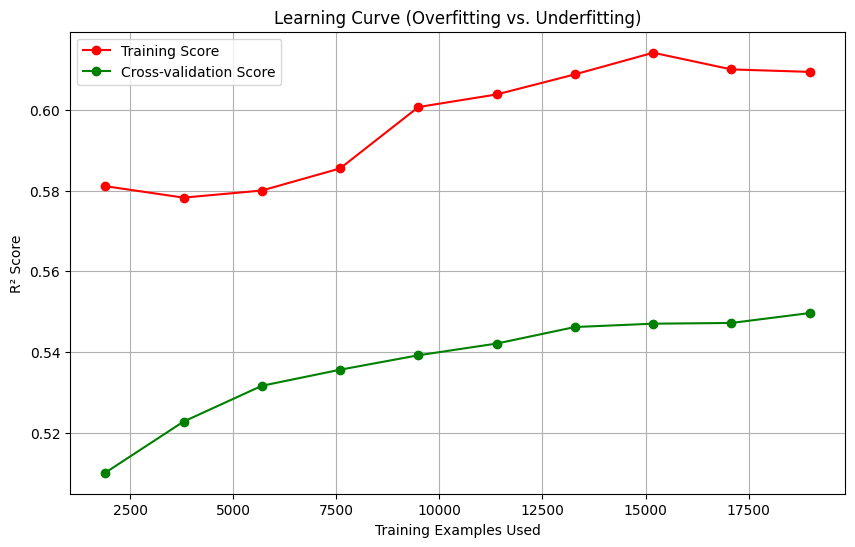

In [138]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# 1. Use the best model found by your grid search
best_model = grid.best_estimator_

# 2. Compute the scores for different training set sizes
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train, 
    cv=5, 
    scoring='r2', 
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# 3. Calculate mean and standard deviation for the lines
train_mean = np.mean(train_scores, axis=1)
# train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
# val_std = np.std(val_scores, axis=1)

# 4. Create the plot
plt.figure(figsize=(10, 6))

# Training Score Line
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training Score")
# plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")

# Validation Score Line
plt.plot(train_sizes, val_mean, 'o-', color="g", label="Cross-validation Score")
# plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color="g")

# Formatting
plt.title("Learning Curve (Overfitting vs. Underfitting)")
plt.xlabel("Training Examples Used")
plt.ylabel("R² Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()